<a href="https://colab.research.google.com/github/MInesGomes/AI-Project2026/blob/main/InesGomes_AI_BusinessProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install numpy pandas scikit-learn matplotlib seaborn imblearn xgboost

##**1. Load Data**

In [2]:
import pandas as pd

In [3]:
#Load the dataset
githubUrl = 'https://raw.githubusercontent.com/MInesGomes/AI-Project2026//main/customer_support.csv'
df = pd.read_csv(githubUrl)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   channel_name             3000 non-null   object 
 1   category                 3000 non-null   object 
 2   Sub-category             3000 non-null   object 
 3   order_date_time          3000 non-null   object 
 4   Issue_reported at        3000 non-null   object 
 5   issue_responded          3000 non-null   object 
 6   Survey_response_Date     3000 non-null   object 
 7   product_category         2955 non-null   object 
 8   Item_price               2955 non-null   float64
 9   connected_handling_time  3000 non-null   float64
 10  csat_score               3000 non-null   int64  
 11  response_time_minutes    3000 non-null   float64
 12  has_handling_time        3000 non-null   int64  
dtypes: float64(3), int64(2), object(8)
memory usage: 304.8+ KB


## **2. Explore the Data**


In [5]:
print(df.columns)

Index(['channel_name', 'category', 'Sub-category', 'order_date_time',
       'Issue_reported at', 'issue_responded', 'Survey_response_Date',
       'product_category', 'Item_price', 'connected_handling_time',
       'csat_score', 'response_time_minutes', 'has_handling_time'],
      dtype='object')



*   **Unique id**: A unique identifier for each customer support ticket. Used for tracking, not used in modeling.
*   **channel_name**: The communication channel used by the customer (e.g., Email, Chat, Phone), which influences response quality and time.
*   **category**: Broad classification of the support issue (e.g., Technical, Billing, Account), useful in understanding issue trends.
*   **Sub-category**: More specific issue label under each category (e.g., "Login Failure" under Technical) to capture granular insights.
*   **Order_id**: The ID of the order associated with the issue; may not be directly useful unless joined with order metadata.
*   **order_date_time**: Timestamp of the order; can be used to derive delays or time gaps relative to issue date.
*   **Issue_reported at**: Time when the customer reported the issue; helps calculate response and resolution delays.
*   **issue_responded**: Time when the support agent responded; combined with report time to calculate response duration.
*   **Survey_response_Date**: Date when customer gave the CSAT feedback; useful to understand follow-up timing, but not always predictive.
*   **Product_category**: The type of product involved in the support ticket; some product types may result in higher or lower CSAT.
*   **Item_price**: Price of the item involved; higher prices might lead to higher customer expectations and affect satisfaction.
*   **connected_handling_time**: Total time spent by the agent resolving the issue; excessive durations may signal complexity or inefficiency.
*   **CSAT Score (Target Variable)**: Customer satisfaction score (1 to 5); the main variable we aim to classify using other features.

In [6]:
print("Descriptive statistics for df_local_csv:")
display(df.describe(include='all'))

Descriptive statistics for df_local_csv:


,channel_name,category,Sub-category,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,product_category,Item_price,connected_handling_time,csat_score,response_time_minutes,has_handling_time
count,3000,3000,3000,3000,3000,3000,3000,2955,2955.000000,3000.000000,3000.000000,3000.000000,3000.0
unique,3,12,46,2038,1709,1636,2,8,NaN,NaN,NaN,NaN,NaN
top,Inbound,Returns,Reverse Pickup Enquiry,2023-07-15 17:49:26.619031022,2023-08-01 19:26:00,2023-08-02 20:16:00,2023-08-02,LifeStyle,NaN,NaN,NaN,NaN,NaN
freq,2333,1408,719,6,8,7,1554,1025,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6557.885167,359.937667,4.203333,155.678000,1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7553.718898,191.496759,1.408066,529.499685,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,63.000000,1.000000,0.000000,1.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2093.064460,264.000000,4.000000,2.000000,1.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2761.142119,282.000000,5.000000,6.000000,1.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10138.979085,433.000000,5.000000,33.000000,1.0


## **3. Data Vizualization**

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the color palette for visualizations
palette = 'hls'
'Set2'

'Set2'

#### CSAT Distribution

/tmp/ipykernel_24068/107988178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="csat_score", palette = palette, legend=False)


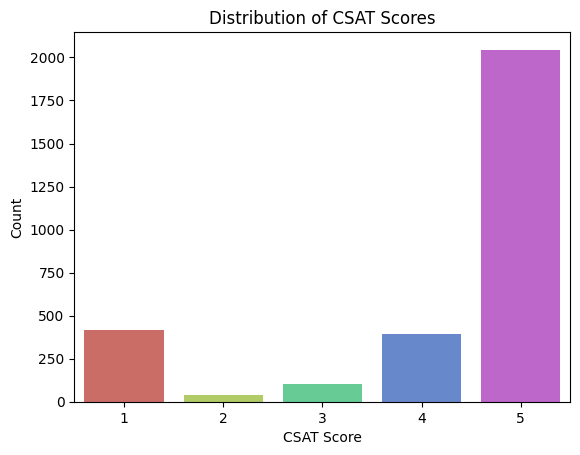

In [8]:
# Visualize the distribution of CSAT Scores using a count plot
sns.countplot(data=df, x="csat_score", palette = palette, legend=False)

# Add title and labels to the plot
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

# Display the plot
plt.show()

The chart reveals a strong positive skew, with the majority of responses being a score of 5, indicating high customer satisfaction. Lower scores, like 2 and 3, are much less frequent.



Understanding that most customers are very satisfied can guide the business to maintain existing practices while focusing on areas of improvement for lower scores. This insight can enhance customer satisfaction strategies.



#### Tickets by Category (Volume)

/tmp/ipykernel_24068/1392071275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="category", order=df['category'].value_counts().index, palette=palette)


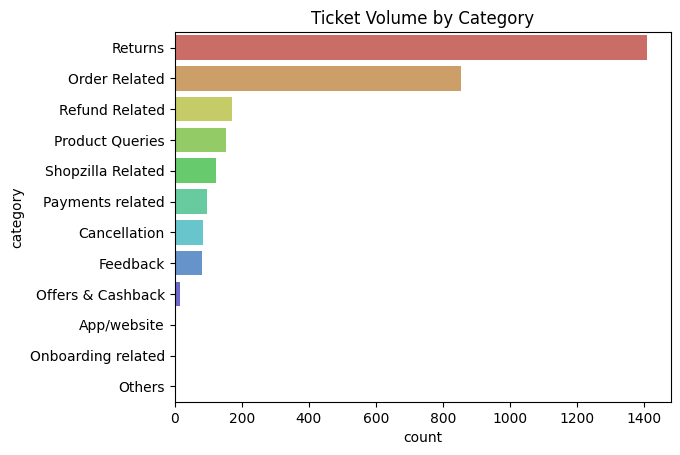

In [9]:
# Visualize ticket volume by category using a count plot
sns.countplot(data=df, y="category", order=df['category'].value_counts().index, palette=palette)

# Add title to the plot
plt.title("Ticket Volume by Category")

# Display the plot
plt.show()

"Returns" and "Order Related" categories have the highest ticket volumes, indicating pain points. "Onboarding related" and "App/website" have the lowest volumes.



By focusing on reducing ticket volumes in high-traffic areas, the business can enhance efficiency and customer satisfaction, leading to better resource allocation.



#### CSAT by Category (Avg Score )

/tmp/ipykernel_24068/3294743223.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='category', y='csat_score', order=mean_scores.index, palette='Set2')


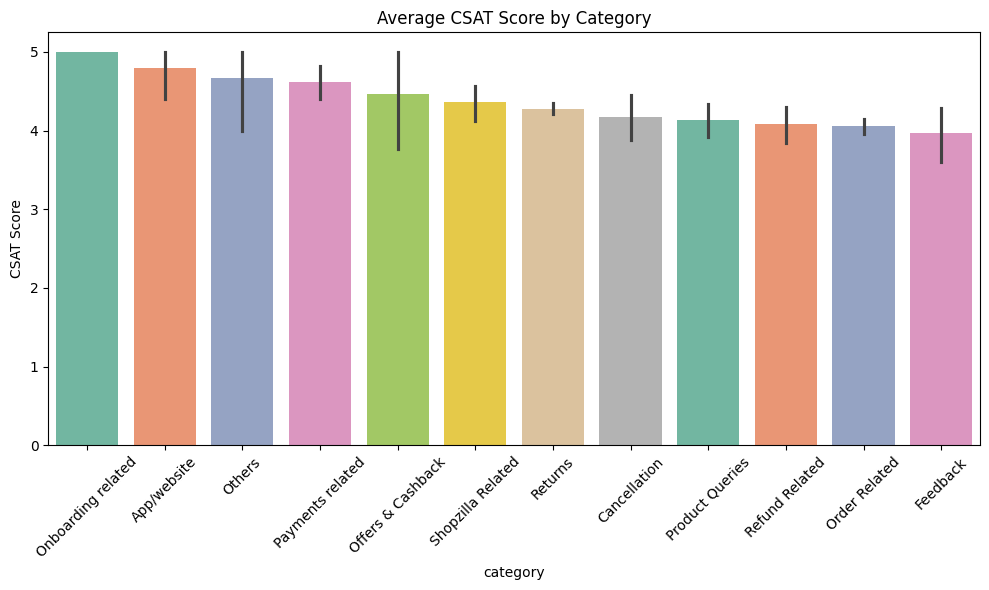

In [10]:
# Calculate the mean CSAT Score for each category and sort in descending order
mean_scores = df.groupby('category')['csat_score'].mean().sort_values(ascending=False)

# Plot the bar chart of mean CSAT Scores by category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='category', y='csat_score', order=mean_scores.index, palette='Set2')

# Add title, rotate x-axis labels, and ylabel
plt.title("Average CSAT Score by Category")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.ylabel("CSAT Score")

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

Scores are generally high across categories, but "Others" has noticeably lower satisfaction. Categories like "App/Website" and "Onboarding" perform well.



By identifying lower satisfaction in the "Others" category, targeted efforts can be made to address specific issues, improving overall customer satisfaction and experience.



#### CSAT by Sub-category (Avg Score )

/tmp/ipykernel_24068/3479769333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sub-category', y='csat_score', palette=palette)


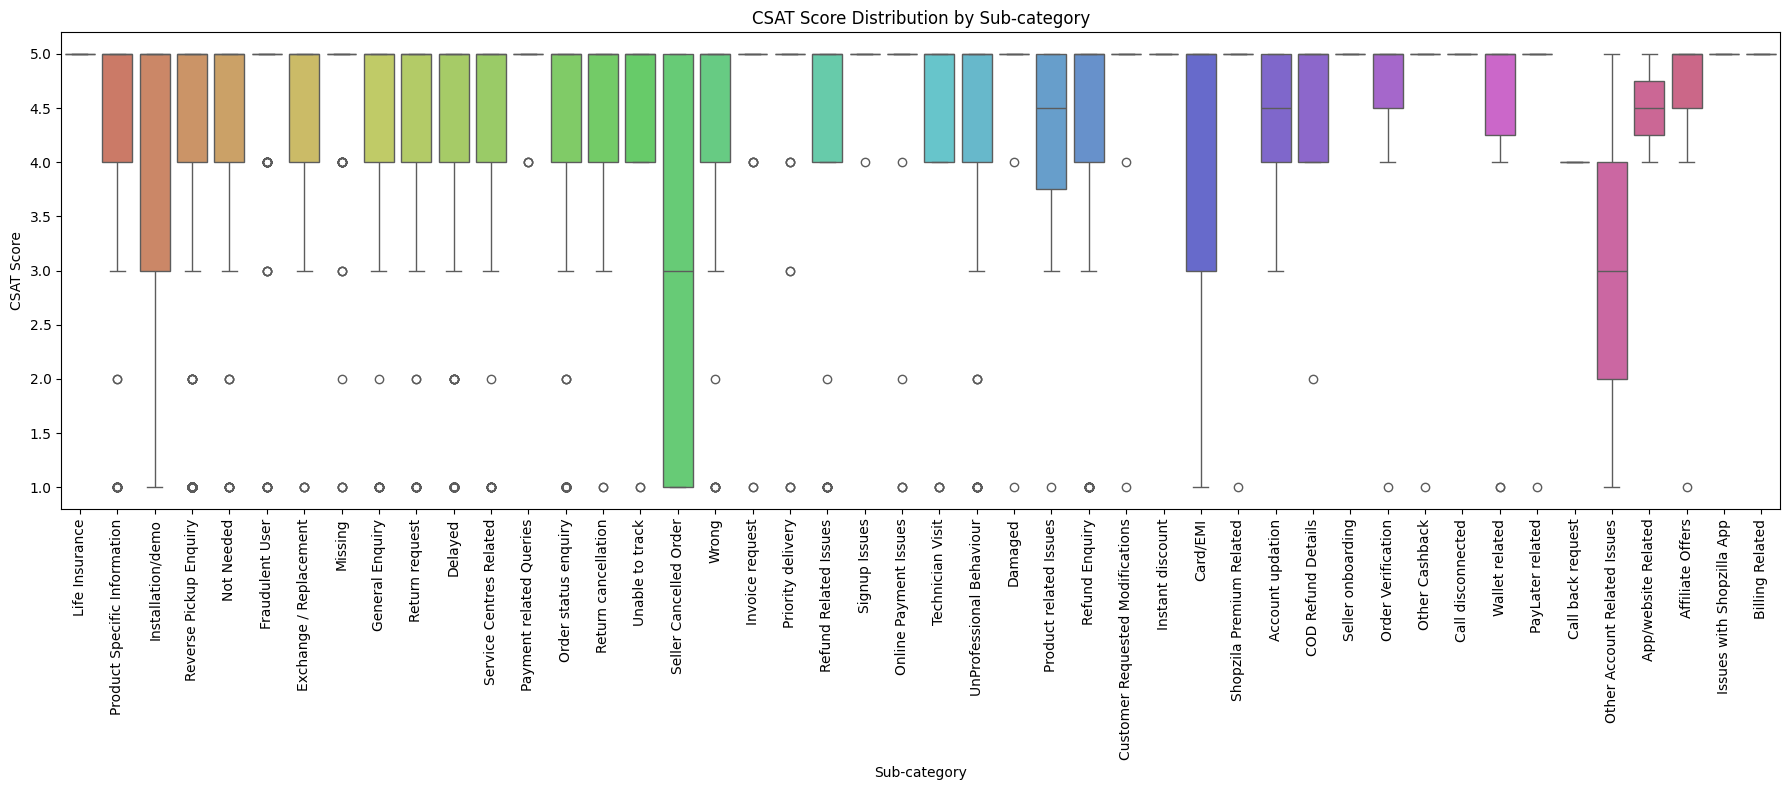

In [11]:
# Set the figure size to be wider to accommodate all sub-categories
plt.figure(figsize=(18, 8))

# Create a box plot for CSAT Score distribution by Sub-category
sns.boxplot(data=df, x='Sub-category', y='csat_score', palette=palette)

# Add title and labels to the plot
plt.title("CSAT Score Distribution by Sub-category")
plt.xticks(rotation=90)  # Rotate x-axis labels for clarity
plt.xlabel("Sub-category")
plt.ylabel("CSAT Score")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

There is significant variability in CSAT scores across sub-categories. Some have high median scores while others show a wider spread and lower scores, indicating areas needing improvement.



Identifying sub-categories with lower scores and higher variability can direct targeted improvements, enhancing overall customer satisfaction and service quality.



In [12]:
#  DROP IRRELEVANT COLUMNS
drop_cols = [
    "Unique id", "Order_id"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [13]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'order_date_time',
       'Issue_reported at', 'issue_responded', 'Survey_response_Date',
       'product_category', 'Item_price', 'connected_handling_time',
       'csat_score', 'response_time_minutes', 'has_handling_time'],
      dtype='object')

In [14]:

#  HANDLE DATETIME COLUMNS
datetime_cols = [
    "order_date_time", "Issue_reported at",
    "issue_responded", "Survey_response_Date"
]
dfNorm = df.copy()
for col in datetime_cols:
    if col in dfNorm.columns:
        dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")

# Feature engineering
dfNorm["report_hour"] = dfNorm["Issue_reported at"].dt.hour
dfNorm["report_day"] = dfNorm["Issue_reported at"].dt.day
dfNorm["report_weekday"] = dfNorm["Issue_reported at"].dt.weekday

dfNorm["response_delay"] = (
    dfNorm["issue_responded"] - dfNorm["Issue_reported at"]
).dt.total_seconds() / 60  # minutes

dfNorm["survey_delay"] = (
    dfNorm["Survey_response_Date"] - dfNorm["issue_responded"]
).dt.total_seconds() / 60

# Drop raw datetime columns
dfNorm = dfNorm.drop(columns=datetime_cols)

In [15]:
dfNorm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   channel_name             3000 non-null   object 
 1   category                 3000 non-null   object 
 2   Sub-category             3000 non-null   object 
 3   product_category         2955 non-null   object 
 4   Item_price               2955 non-null   float64
 5   connected_handling_time  3000 non-null   float64
 6   csat_score               3000 non-null   int64  
 7   response_time_minutes    3000 non-null   float64
 8   has_handling_time        3000 non-null   int64  
 9   report_hour              3000 non-null   int32  
 10  report_day               3000 non-null   int32  
 11  report_weekday           3000 non-null   int32  
 12  response_delay           3000 non-null   float64
 13  survey_delay             3000 non-null   float64
dtypes: float64(5), int32(3),

**Preparing Data for Model Training**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

In [17]:
# Separate features (X) and target variable (y) for modeling
X = dfNorm.drop(columns=['csat_score'])  # Features: all columns except 'csat_score'
y = dfNorm['csat_score']                # Target: customer satisfaction score (csat_score)

Separated features and target variable for modeling purposes. Assigned `X` to all columns except `csat_score` to use as features, and set `y` to `csat_score`, representing the target variable for customer satisfaction prediction.

In [18]:
# Displays the number of samples and features
X.shape

(3000, 13)

##**4. Feature Selection**

#### Feature Importance with RandomForestClassifier

In [19]:
# Import necessary libraries for the model and preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate numerical and categorical columns
numeric_cols = X.select_dtypes(include='number').columns.tolist()  # List of numerical feature names
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()  # List of categorical feature names

# Create preprocessing transformer
preprocessor = ColumnTransformer([
    # Impute missing values in numerical columns with the mean
    ('num', SimpleImputer(strategy='mean'), numeric_cols),

    # Impute missing values in categorical columns with the most frequent value
    # Then encode categories as ordinal numbers, handling unknowns
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), categorical_cols)
])

# Build a pipeline that includes preprocessing and a Random Forest classifier
pipeline = Pipeline([
    ('preprocess', preprocessor),  # Apply preprocessing steps
    ('rf', RandomForestClassifier(  # Initialize the Random Forest model
        n_estimators=50,             # Use 50 trees in the forest
        max_depth=10,                # Limit the depth of trees to 10
        max_features='sqrt',         # Split nodes with sqrt of total features
        min_samples_split=10,        # Require at least 10 samples to split a node
        n_jobs=-1,                   # Use all available cores
        random_state=42              # Set random state for reproducibility
    ))
])

# Fit the pipeline on the data
pipeline.fit(X, y)  # Train the model with the features and target

# Retrieve feature importances from the trained model
feature_names = numeric_cols + categorical_cols  # Combine all feature names
importances = pipeline.named_steps['rf'].feature_importances_  # Get importance scores

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,      # Column with feature names
    'importance': importances      # Corresponding importance scores
}).sort_values(by='importance', ascending=False)


**Calculate cumulative importance scores**

In [20]:
# Calculate cumulative importance scores
feature_importance_df['cumulative_importance'] = feature_importance_df['importance'].cumsum()

# Set option to display all rows
pd.set_option('display.max_rows', None)

# Display the updated DataFrame, sorted by importance
print(feature_importance_df.sort_values(by='importance', ascending=False))

                    feature  importance  cumulative_importance
8              survey_delay    0.159336               0.159336
7            response_delay    0.150246               0.309581
2     response_time_minutes    0.147627               0.457208
0                Item_price    0.127266               0.584474
4               report_hour    0.087859               0.672333
11             Sub-category    0.083947               0.756280
1   connected_handling_time    0.062828               0.819108
10                 category    0.049518               0.868625
12         product_category    0.046296               0.914921
9              channel_name    0.032649               0.947570
5                report_day    0.028547               0.976117
6            report_weekday    0.023883               1.000000
3         has_handling_time    0.000000               1.000000


**Selecting Manually Chosen Features from Dataset**

In [21]:
# Manually selected features
manually_selected_features = ['response_delay', 'response_time_minutes','Item_price', 'survey_delay',
                              'connected_handling_time','category','report_day','report_hour','product_category'  ]

# Select these features from your dataset X
X = X[manually_selected_features]

print("Shape of dataset with manually selected features:", X.shape)


Shape of dataset with manually selected features: (3000, 9)


Manually selected a set of features deemed significant based on domain knowledge and analysis. These features include `Chance_to_Churn`, `sentiment_score`, `response_time_minutes`, `is_long_response`, `time_from_order_to_response`, `avg_csat_by_agent`, `sentiment_label`, `Item_price`, `time_from_order_to_issue_reported`, `category_subcategory`, `product_category`, `order_hour`, `connected_handling_time`, `Tenure Bucket`, `agent_shift`, and `channel_name`.

Filtered the dataset to include only these features, resulting in a refined dataset, and displayed its shape to confirm the selection.

In [22]:
#Display the column names after feature Selection
X.columns

Index(['response_delay', 'response_time_minutes', 'Item_price', 'survey_delay',
       'connected_handling_time', 'category', 'report_day', 'report_hour',
       'product_category'],
      dtype='object')

 #### Ordinal Encoding and OneHot encoding

In [23]:
# Display the DataTypes of features in X
X.dtypes

,0
response_delay,float64
response_time_minutes,float64
Item_price,float64
survey_delay,float64
connected_handling_time,float64
category,object
report_day,int32
report_hour,int32
product_category,object


Displayed the data types of manually selected features in `X`. This insight confirms the diversity of data types, including integers, floats, objects, and categorical types. Understanding the data types is crucial for ensuring appropriate handling during preprocessing and modeling.

In [24]:
# Drop rows with null values in the feature set X
non_null_index = X.dropna().index  # Get indices of rows without nulls

# Align X and y to only include non-null rows
X = X.loc[non_null_index]  # Select non-null rows in X using the indices
y = y.loc[non_null_index]  # Align y with X by selecting the same indices

# Print the shapes of the aligned datasets
print(f"X shape: {X.shape}\nY shape: {y.shape}")

X shape: (2955, 9)
Y shape: (2955,)


Aligned the feature set `X` and target `y` by removing rows with null values in `X`. This ensures consistency and reliability in the dataset used for modeling. After dropping nulls, both `X` and `y` share the same indices, resulting in shapes of `X shape: (84810, 15)` and `Y shape: (84810,)`. This indicates that there are 84,810 samples with 15 features ready for analysis.

**Preprocessing Selected Features with Ordinal and One-Hot Encoding**

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# List of manually selected features
selected_features = X.columns

# Define one-hot encoding features
onehot_features = ['product_category','category' ]

# Identify numerical features
used_features =  onehot_features
numerical_features = [f for f in selected_features if f not in used_features]

# ColumnTransformer setup for encoding
column_transformer = ColumnTransformer(
    transformers=[
        # One-hot encoding for categorical features
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), onehot_features)
    ],
    remainder='passthrough'  # Keep numerical columns unchanged
)

# Select only the desired features from X
df_selected = X[selected_features]

# Apply transformations: fit and transform
X_transformed = column_transformer.fit_transform(df_selected)

# Retrieve names of one-hot encoded features
ohe_feature_names = column_transformer.named_transformers_['ohe'].get_feature_names_out(onehot_features)

# Combine all feature names: ordinal, one-hot, and numerical
final_feature_names = list(ohe_feature_names) + numerical_features

# Convert the transformed array back to a DataFrame
X = pd.DataFrame(X_transformed, columns=final_feature_names)

# Output the shape of the transformed DataFrame
print(f"Transformed X shape: {X.shape}")

Transformed X shape: (2955, 25)


The code transforms the dataset `X` by encoding features. It applies ordinal encoding to the `sentiment_label` feature and one-hot encoding to categorical features like `category_subcategory`, `product_category`, `Tenure Bucket`, `agent_shift`, and `channel_name`. Numerical features remain unchanged. A `ColumnTransformer` is set up for this process, which transforms the data and retrieves names for one-hot encoded features. The final DataFrame `X` combines all encoded and numerical features.Final X shape: (84810, 33)

### Categorical Encoding Techniques Used

2. **One-Hot Encoding:**
   - Applied to `category_subcategory`, `product_category`, `Tenure Bucket`, `agent_shift`, and `channel_name`. This approach handles nominal categories without implying any order, converting them into binary vectors that are suitable for machine learning models.

These techniques are selected to accurately represent categorical data and ensure the model interprets the data correctly.

##**5. Feature Manipulation & Selection**

In [26]:
# Print the count of each data type in the DataFrame X
print(X.dtypes.value_counts())

float64    25
Name: count, dtype: int64


The DataFrame `X` has 69 features, all of which are `float64`. This consistency comes from encoding categorical variables into numerical formats, making them suitable for machine learning models.

**Remove Constant or Near-Constant Columns**



In [27]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Assuming X is a DataFrame
selector = VarianceThreshold(threshold=0.01)

# Fit the selector
selector.fit(X)

# Get the mask of the selected features
mask = selector.get_support()

# Use the mask to select features from the original DataFrame
X_reduced = X.loc[:, mask]

# Update X
X = X_reduced

# Check the shape
print(X.shape)

(2955, 21)


In [28]:
X.columns

Index(['product_category_Books & General merchandise',
       'product_category_Electronics', 'product_category_Home',
       'product_category_Home Appliences', 'product_category_LifeStyle',
       'product_category_Mobile', 'category_Cancellation', 'category_Feedback',
       'category_Order Related', 'category_Payments related',
       'category_Product Queries', 'category_Refund Related',
       'category_Returns', 'category_Shopzilla Related', 'response_delay',
       'response_time_minutes', 'Item_price', 'survey_delay',
       'connected_handling_time', 'report_day', 'report_hour'],
      dtype='object')

In [29]:
print(X.shape)

(2955, 21)


The `VarianceThreshold` method is used to remove low-variance features from the dataset `X`. A threshold of 0.01 is set, so features with variance below this value are removed. The selector is fit and applied to `X`, retaining only high-variance features. The transformed dataset has a shape of (84810, 30), indicating that the features have been reduced from 33 to 30. This enhances model efficiency by eliminating less informative features.

Feature selection methods utilized include:

1. **VarianceThreshold:**
   - This method removes features with low variance, identifying those that contribute little to model performance. By setting a threshold of 0.01, features with minimal variability are eliminated, enhancing model efficiency and focus.

2. **Random Forest Classifier for Feature Importance:**
   - Used to assess and rank feature importance. This method helps in identifying and retaining the most impactful features based on their contribution to the model, ensuring that only significant features are considered for predictive accuracy.

These methods streamline the dataset by removing redundant features, simplifying the model, and improving performance.

### 5. Data Transformation

Transforming the data is essential to improve model performance and interpretability. The transformations applied include:

- **Encoding Categorical Features:** I've already applied ordinal encoding for ordered categories like `sentiment_label` and one-hot encoding for nominal features such as `category_subcategory` and `channel_name`. This ensures categorical data is represented numerically for model compatibility.

- **VarianceThreshold:** This has been used to remove low-variance features, refining the dataset to include only impactful features for efficient modeling.

- **Feature Scaling:** I plan to apply techniques like standardization to ensure numerical features such as `response_time_minutes` and `item_price` have a similar scale, enhancing model convergence.

These transformations are crucial for ensuring the dataset is clean, relevant, and ready for machine learning tasks, allowing the model to learn effectively from the data.

### 6. Data Splitting

In [30]:
# Stratified splitting to maintain the class balance in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # 20% of data for testing
)

I used an **80:20 stratified train-test split** to ensure the model has sufficient training data while preserving the class distribution in both sets. This helps maintain balanced representation for accurate evaluation.


### 7. Data Scaling

In [31]:
# Import MinMaxScaler for feature scaling
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler to scale features to a range between 0 and 1
scaler = MinMaxScaler()

# Fit the scaler on the data and transform it
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)


I've used the `MinMaxScaler` to scale data to a range between 0 and 1. While tree-based models and Naive Bayes don't require feature scaling, applying MinMaxScaler can still be beneficial. It ensures uniform feature scaling, which might help with interpretability and when combining models in ensembles or pipelines.

### 7. Dimesionality Reduction

Further dimensionality reduction is not necessary at this stage. I've already performed feature selection and retained the top 15 most important features. Additionally, I've applied categorical encoding and used a variance threshold to bring the total number of features down to 30. This process reduces noise, avoids overfitting, and preserves the most relevant information for modeling, making additional techniques like PCA unnecessary.

### 9. Handling Imbalanced Dataset

In [32]:
import sys
!{sys.executable} -m pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import sys
    !{sys.executable} -m pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** is a method used to handle imbalanced datasets by generating synthetic samples for the minority class. Instead of duplicating existing minority instances, SMOTE creates new samples by interpolating between each minority example and its nearest neighbors. This process helps balance the class distribution, reduce overfitting, and improve model generalization. With a more balanced dataset, models can learn more effectively, enhancing their ability to accurately predict minority class instances and leading to more robust performance.

In [33]:
y_train.value_counts()

,count
csat_score,
5,1605
1,334
4,314
3,81
2,30


The dataset shows a significant class imbalance, with the majority class (score 5) vastly outnumbering others, especially scores 3 and 2. This imbalance can bias the model towards predicting the majority class, leading to suboptimal performance on the minority classes.

SMOTE (Synthetic Minority Over-sampling Technique) is essential in this scenario. It generates synthetic samples for the minority classes by interpolating between existing instances. This balances the dataset, allowing models to learn more effectively and improving their ability to predict all classes accurately. By applying SMOTE, we aim to enhance model generalization and performance across all class labels.

In [34]:
import sklearn
import imblearn
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

scikit-learn: 1.6.1
imbalanced-learn: 0.14.1


In [35]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [36]:
y_train.value_counts()

,count
csat_score,
5,1605
4,1605
1,1605
3,1605
2,1605


After applying SMOTE, the `csat_score` distribution is balanced, with each class having 47,018 instances. This uniform distribution ensures that the model can learn equally from all classes, improving its ability to make accurate predictions across different categories.

The dataset appears to be imbalanced because the target variable (csat_score) does not have an even distribution across its classes. Some classes occur significantly more frequently than others, which can bias the model toward the majority class and reduce performance on minority classes.



I used **SMOTE (Synthetic Minority Over-sampling Technique)** to handle the class imbalance in the dataset. SMOTE generates synthetic samples for the minority class by interpolating between existing minority class examples, rather than simply duplicating them. This helps the model learn a more generalizable decision boundary.

I applied SMOTE **only to the training data** to avoid data leakage and ensure that model evaluation on the test set reflects real-world performance.

Used SMOTE because it:
- Balances the classes effectively without losing any data (unlike undersampling).
- Improves model performance on minority classes (e.g., recall, F1-score).
- Works well with many classifiers like Logistic Regression, Random Forest, SVM, etc.
- Reduces the risk of overfitting compared to naive oversampling by duplication.


## **6. Model Implementation**

In [37]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'order_date_time',
       'Issue_reported at', 'issue_responded', 'Survey_response_Date',
       'product_category', 'Item_price', 'connected_handling_time',
       'csat_score', 'response_time_minutes', 'has_handling_time'],
      dtype='object')

In [38]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

#  CREATE TARGET VARIABLE (High CSAT)
dfClean = dfNorm.copy()
dfClean = dfClean.dropna(subset=["csat_score"])
dfClean["high_csat"] = (dfClean["csat_score"] >= 4).astype(int)

# Drop original CSAT column
dfClean = dfClean.drop(columns=["csat_score"])

#  HANDLE MISSING VALUES

# Numeric columns → fill with median
numeric_cols = dfClean.select_dtypes(include=[np.number]).columns
dfClean[numeric_cols] = dfClean[numeric_cols].fillna(dfClean[numeric_cols].median())

# Categorical columns → fill with "Unknown"
categorical_cols = dfClean.select_dtypes(include=["object"]).columns
dfClean[categorical_cols] = dfClean[categorical_cols].fillna("Unknown")

#  ENCODE CATEGORICAL FEATURES
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    dfClean[col] = le.fit_transform(dfClean[col].astype(str))
    label_encoders[col] = le

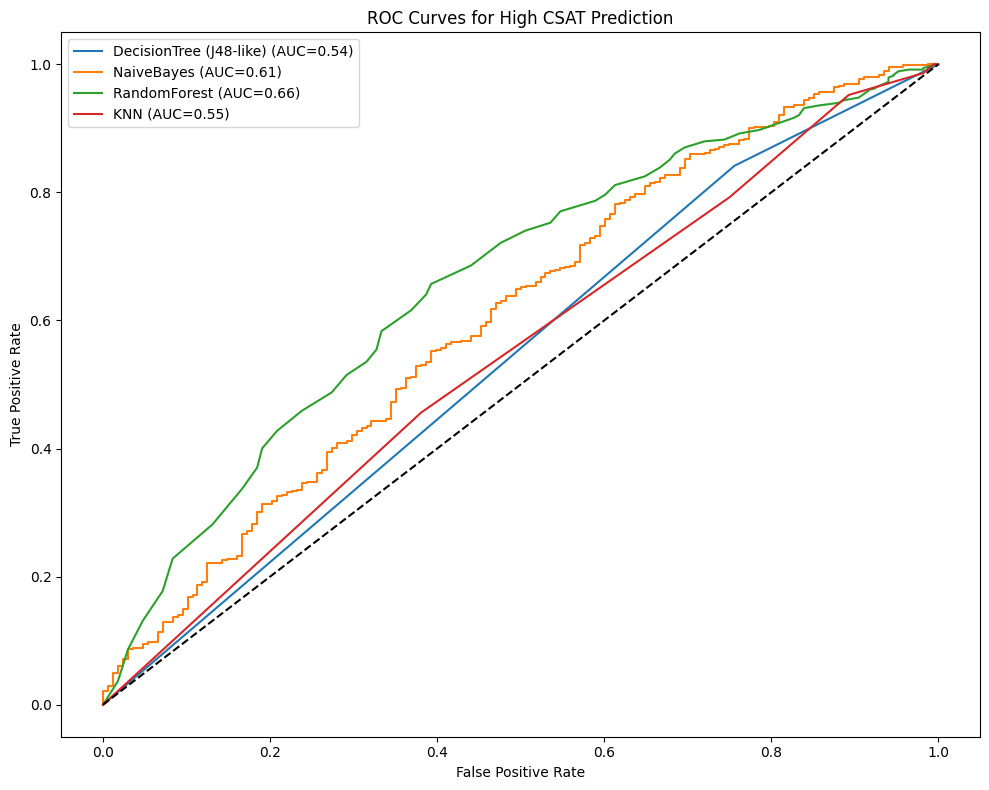

In [39]:
#  TRAIN-TEST SPLIT
X = dfClean.drop(columns=["high_csat"])
y = dfClean["high_csat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#  TRAIN MODELS
models = {
    "DecisionTree (J48-like)": DecisionTreeClassifier(random_state=42),
    "NaiveBayes": GaussianNB(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probability for ROC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({"model": name, "accuracy": acc, "roc_auc": roc_auc})

    # Plot ROC
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# ROC plot
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for High CSAT Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

##**7. Accuracy Comparison**


Model Comparison:
                     model  accuracy   roc_auc
0  DecisionTree (J48-like)  0.730000  0.542789
1               NaiveBayes  0.797778  0.606818
2             RandomForest  0.798889  0.659950
3                      KNN  0.794444  0.546241


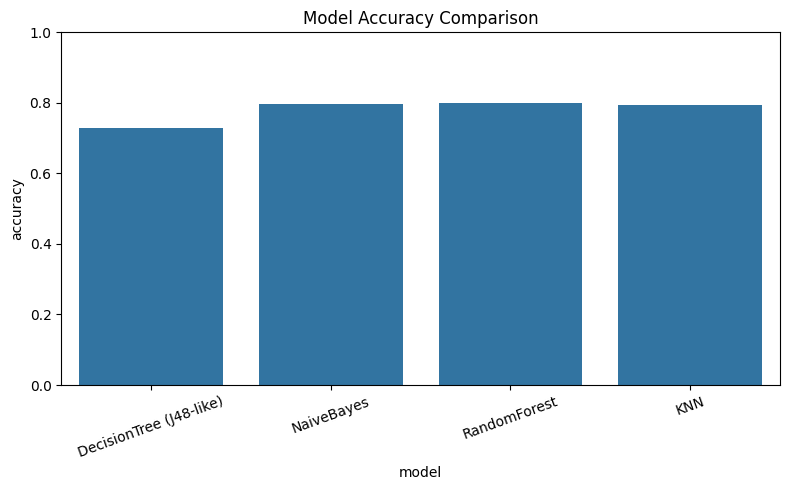


Best Model: RandomForest
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT             12            156
True_HighCSAT            25            707


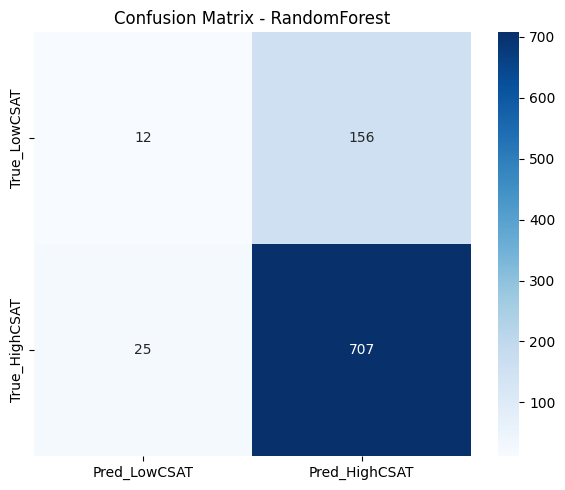

In [40]:

# 9. ACCURACY COMPARISON


results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="model", y="accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()


# 10. CONFUSION MATRIX FOR BEST MODEL


best_model_name = results_df.sort_values(by="accuracy", ascending=False).iloc[0]["model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["True_LowCSAT", "True_HighCSAT"],
    columns=["Pred_LowCSAT", "Pred_HighCSAT"]
)

print(f"\nBest Model: {best_model_name}")
print("Confusion Matrix:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [41]:
from sklearn.metrics import classification_report

# Assuming y_test and y_pred_best are available from the previous step
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Low CSAT', 'High CSAT']))


Classification Report for RandomForest:
              precision    recall  f1-score   support

    Low CSAT       0.32      0.07      0.12       168
   High CSAT       0.82      0.97      0.89       732

    accuracy                           0.80       900
   macro avg       0.57      0.52      0.50       900
weighted avg       0.73      0.80      0.74       900

